# Null hypothesis testing: evidence and decisions

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/06-null-hypothesis-testing.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

The data we are dealing with in practice are a finite sample from a larger -- most likely infinite -- population of possible observations. That population may be a physical process operating over time, manufactured parts produced under the same conditions, or outcomes that could have occurred under comparable conditions. We use the sample to **infer** properties of the population.

That inference comes with uncertainty because a different sampling trial could have produced a different result (e.g., a different **collection** of observations). Null hypothesis testing gives us a disciplined way to ask whether an observed result is surprising under a reference claim about the population. 

**Learning objectives**

- State a null hypothesis and an alternative hypothesis for a population mean.
- Use simulation to construct a null distribution for a sample mean.
- Interpret a two-sided p-value and a significance level.
- Distinguish statistical significance from practical importance and causality.

## 1. An engineering question

Suppose a machining process is intended to produce shafts with a diameter of **20.00 mm**. Due to the inevitable variability during the manufacturing process, the diameters of the shafts produced will vary. However, we would assume the distribution of diameters is centered at 20.00 mm, i.e., the population mean is 20.00 mm. A quality engineer samples 25 shafts and obtains a sample mean of **20.20 mm**, with the sample standard deviation of **0.40 mm**.

The sample mean is above the target, but seemingly close to it. Is a difference of 0.20 mm evidence that the process (i.e., population) mean is different from 20.00 mm, or could it plausibly be ordinary sampling variation?

## 2. From observations to a population claim

The 25 measured shafts are our **sample**. The quantity we want to learn about is the process's long-run mean diameter across the much larger population of shafts it could produce. We cannot measure that entire population, so we use the sample mean to infer its mean.

The observed mean is 0.20 mm above the target. There are two broad explanations: ordinary sampling variation from a process still centered at 20.00 mm, or evidence that the process mean is genuinely different. Null hypothesis testing makes that comparison precise by asking how surprising this sample would be under the first explanation.

## 3. State the competing hypotheses

Let $\mu$ be the true, long-run mean shaft diameter for this process. The **null hypothesis** is the reference claim we want to examine:

$$H_0: \mu = 20.00\text{ mm}$$

The **alternative hypothesis** describes the kind of departure we care about:

$$H_A: \mu \ne 20.00\text{ mm}$$

This is a **two-sided** test because a mean that is too small or too large would both be evidence against the target. The hypotheses are statements about the population mean, not about the particular sample we happened to measure.

## 4. Simulate the null world

To assess the observed mean, imagine repeatedly taking new samples of 25 shafts **in a world where $H_0$ is true**. For this simulation, we make a deliberate shortcut: we use the observed sample standard deviation, $S = 0.40$ mm, as if it were the population standard deviation, $\sigma$.

We also assume that individual shaft diameters follow a normal distribution centered at 20.00 mm. We start with a Normal population because it makes the result especially clean: the mean of 25 such shafts is exactly Normally distributed. This is not a requirement for using a Normal-shaped null distribution of sample means. The central limit theorem (CLT) explains why a similar pattern can arise even when the individual diameters are not Normal.

For each repetition, we draw 25 individual diameters and calculate their sample mean. Repeating that process produces a **null distribution**: the values of the test statistic (here, the sample mean) that would arise if the process had not shifted. According to CLT, the null distribution is a Normal distribution, centered at 20.00 mm, with standard error $0.40 / \sqrt{25} = 0.08$ mm. 

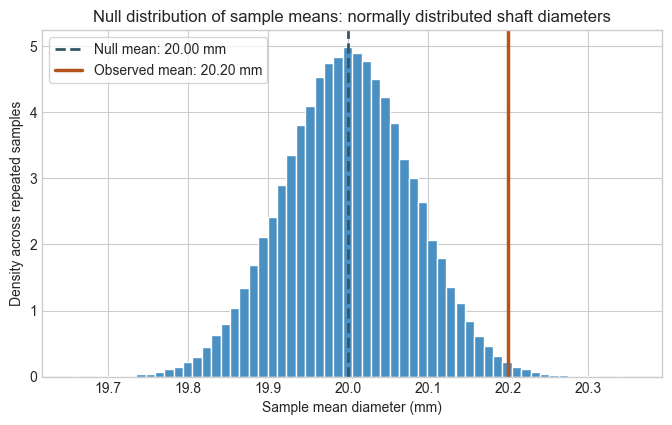

In [1]:
# NumPy simulates repeated samples; Matplotlib displays their distributions.
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(4520)

target_mean = 20.00  # mm: the null population mean
observed_mean = 20.20  # mm: the measured sample mean
sample_sd = 0.40  # mm: the measured sample standard deviation
sample_size = 25

# Teaching shortcut: use the sample SD as the population SD in this simulation.
population_sd = sample_sd
standard_error = population_sd / np.sqrt(sample_size)

n_repetitions = 100_000
# Each row is one hypothetical quality sample of 25 normally distributed shafts
# from a process whose population mean is still the target mean.
normal_null_samples = rng.normal(
    loc=target_mean,
    scale=population_sd,
    size=(n_repetitions, sample_size),
)
null_means = normal_null_samples.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_means, bins=60, density=True, color="#4a90c2", edgecolor="white")
ax.axvline(target_mean, color="#355766", linestyle="--", linewidth=2, label="Null mean: 20.00 mm")
ax.axvline(observed_mean, color="#b65420", linewidth=2.5, label="Observed mean: 20.20 mm")
ax.set(
    xlabel="Sample mean diameter (mm)",
    ylabel="Density across repeated samples",
    title="Null distribution of sample means: normally distributed shaft diameters",
)
ax.legend(frameon=True)
plt.show()

## 5. Calculate and interpret a p-value

The observed mean is 0.20 mm from the null mean. For a two-sided test, we count simulated means at least that far away **in either direction**. The resulting proportion is the p-value.

$$p\text{-value} = P\left(\left|\bar{X} - 20.00\right| \geq \left|20.20 - 20.00\right| \;\middle|\; H_0\right)$$

Read the vertical bar as *assuming the null hypothesis is true*. A p-value is **not** the probability that $H_0$ is true. It is the probability of seeing a result at least this unusual if $H_0$ were true.

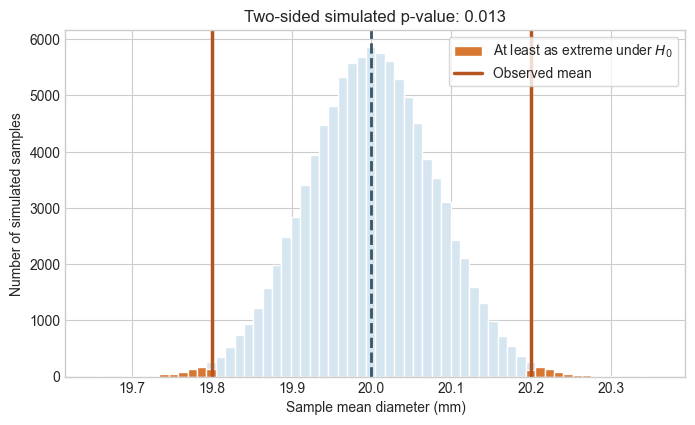

Observed distance from the target: 0.20 mm
Estimated two-sided p-value: 0.013


In [2]:
observed_distance = abs(observed_mean - target_mean)
as_extreme = abs(null_means - target_mean) >= observed_distance
p_value = as_extreme.mean()

bin_edges = np.linspace(null_means.min(), null_means.max(), 61)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_means, bins=bin_edges, color="#d6e6f1", edgecolor="white")
ax.hist(
    null_means[as_extreme], bins=bin_edges,
    color="#d77732", edgecolor="white", label="At least as extreme under $H_0$"
)
ax.axvline(target_mean, color="#355766", linestyle="--", linewidth=2)
ax.axvline(observed_mean, color="#b65420", linewidth=2.5, label="Observed mean")
ax.axvline(2 * target_mean - observed_mean, color="#b65420", linewidth=2.5)
ax.set(
    xlabel="Sample mean diameter (mm)",
    ylabel="Number of simulated samples",
    title=f"Two-sided simulated p-value: {p_value:.3f}",
)
ax.legend(frameon=True)
plt.show()

print(f"Observed distance from the target: {observed_distance:.2f} mm")
print(f"Estimated two-sided p-value: {p_value:.3f}")

## 6. Turn evidence into a decision

The p-value tells us how surprising the observed mean would be under the first explanation, i.e., Null hypothesis $H_0$: ordinary sampling variation from a process still centered at 20.00 mm. To turn that evidence into a principled decision framework, we need to choose a decision threshold (for the p-value) **before** seeing the data.

This threshold is called the **significance level**, $\alpha$. A commonly used value is $\alpha = 0.05$. With this choice, we reject $H_0$ when the p-value is below 0.05; otherwise, we **fail to reject** $H_0$. The choice of $\alpha$ should reflect the consequence of falsely declaring that the process has shifted. If $H_0$ is actually true, a rule with $\alpha = 0.05$ makes a **Type-I error**—a false rejection—about 5% of the time in the long run.

The **rejection region** is the set of sample-mean values for which our testing procedure rejects $H_0$. Before seeing the sample outcome, we choose the test to be two-sided, choose $\alpha$, and specify the reference distribution. The numerical boundaries can still depend on an estimated quantity. Here, because the population standard deviation is unknown, we plug the observed $S = 0.40$ mm into $\sigma$ to calculate them.

In a two-sided test with $\alpha = 0.05$, the intended rejection region contains the outer 5% of the null distribution: 2.5% in each tail. Under the null model, this gives a Type-I error rate of about 5% in the long run.

For this Normal/CLT reference calculation, the two-sided 5% rule uses 1.96 standard errors from the target:

$$
\bar{X} < 20.00 - 1.96(0.08) = 19.843\text{ mm}
\qquad\text{or}\qquad
\bar{X} > 20.00 + 1.96(0.08) = 20.157\text{ mm}.
$$

The shaded tails below are the plug-in rejection region for $S = 0.40$ mm. The testing procedure is pre-specified; after obtaining $S$, we calculate its numerical boundaries and check whether $\bar{X}=20.20$ mm falls inside them.


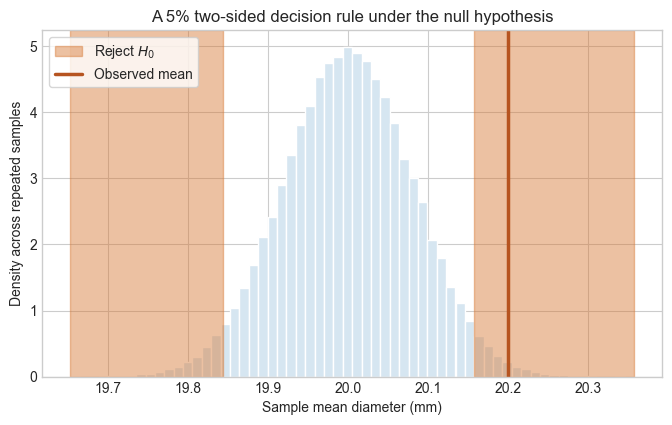

Reject H₀ below 19.843 mm or above 20.157 mm.
Simulated Type-I error rate: 0.051
Decision for this sample: reject H₀


In [3]:
alpha = 0.05
z_critical = 1.96
critical_distance = z_critical * standard_error
lower_cutoff = target_mean - critical_distance
upper_cutoff = target_mean + critical_distance
type_i_error_rate = np.mean(
    (null_means <= lower_cutoff) | (null_means >= upper_cutoff)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(null_means, bins=60, density=True, color="#d6e6f1", edgecolor="white")
ax.axvspan(null_means.min(), lower_cutoff, color="#d77732", alpha=0.45, label="Reject $H_0$")
ax.axvspan(upper_cutoff, null_means.max(), color="#d77732", alpha=0.45)
ax.axvline(observed_mean, color="#b65420", linewidth=2.5, label="Observed mean")
ax.set(
    xlabel="Sample mean diameter (mm)",
    ylabel="Density across repeated samples",
    title="A 5% two-sided decision rule under the null hypothesis",
)
ax.legend(frameon=True)
plt.show()

print(f"Reject H₀ below {lower_cutoff:.3f} mm or above {upper_cutoff:.3f} mm.")
print(f"Simulated Type-I error rate: {type_i_error_rate:.3f}")
print("Decision for this sample:", "reject H₀" if p_value < alpha else "fail to reject H₀")

> **Decision at $\alpha = 0.05$.** The simulated p-value is about 0.013, below the pre-specified 5% threshold. We therefore **reject $H_0$**: under this null model, the data provide evidence against the explanation that the process is still centered at 20.00 mm. This decision does not prove that the process mean has shifted.

### Try it

Keep the observed difference at 0.20 mm, but change the sample size. What happens to the standard error and to the simulated p-value when you use 9, 25, or 100 shafts?

In [4]:
# Try one sample size at a time.
# my_sample_size = 100
# my_standard_error = process_sd / np.sqrt(my_sample_size)
# my_null_means = rng.normal(target_mean, my_standard_error, size=100_000)
# my_p_value = np.mean(abs(my_null_means - target_mean) >= observed_distance)
# print(f"Standard error: {my_standard_error:.3f} mm")
# print(f"Simulated p-value: {my_p_value:.3f}")

## 7. What statistical significance does—and does not—say

A small p-value is evidence that the observed result would be unusual under the null model. It does **not** tell us:

- the probability that the null hypothesis is true;
- whether a detected shift is large enough to matter for engineering tolerances;
- whether one variable causes another to change.

A larger sample can make a very small deviation statistically significant. Always report an estimated effect and its confidence interval alongside a p-value, then use engineering judgment to decide whether the effect matters.

In the Regression series, we will apply the same logic to a slope. There, the null hypothesis will be $H_0: \beta_1 = 0$: no linear association between a predictor and the response in the model.

## Check-in

1. In the shaft example, what population quantity does $\mu$ represent?
2. In your own words, what assumption is made when calculating the p-value?
3. If the p-value is 0.03 and $\alpha = 0.05$, what is the decision? What can you **not** conclude from that decision?

[Return to the Foundations page](index.qmd)